# CatBoost

## 1. Imports and warning filters

In [3]:
import math
import os
import pickle
import re
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from joblib import Parallel, delayed
from matplotlib.patches import Patch
from sklearn import metrics
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


## 2. Settings

In [6]:
DATA_FILE = "DatasetIPMM3.xlsx"
OUTPUT_DIR = Path("CatBoost")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_COL = "Capacitance"
MONOMER_COL = "Monomer"
POLYMER_COL = "Polymer_Type"

RANDOM_STATE_SPLIT = 100
RANDOM_STATE_MODEL = 42
TEST_SIZE = 0.20
USE_STRATIFIED_SPLIT = False
REUSE_EXISTING_SPLIT_FILE = True
SPLIT_FILE_CANDIDATES = [
    Path("Light GBM") / "Data_Split_Assignment.xlsx",
    Path("LGBM_combined_PANI_PPy_SHAP_fixed_outputs") / "Data_Split_Assignment.xlsx",
    Path("Data_Split_Assignment.xlsx"),
]

CV_MODE = "original"
CV_SPLITS = 5
ALPHA_OVERFIT_GAP = 1.0

RUN_GRID_SEARCH = True
GRID_VERBOSE = 2
GRID_N_JOBS = -1

WRITE_PER_FEATURE_SHAP_PLOTS = True
RUN_PDP2D_INTERACTIONS = True
MIN_CELL_N_FOR_SUPPORTED_PDP2D = 5
MAX_NUMERIC_GRID_VALUES = 15
MIN_VALUE_COUNT_FOR_NUMERIC_GRID = 3

numerical_features = [
    "OMR", "SSA", "AMR", "BR", "CR", "ACN", "Molarity", "PW", "CD"
]
categorical_features = [
    "Monomer", "Dopant", "Template", "Oxidant", "Electrolyteclass", "Configuration"
]
feature_names = numerical_features + categorical_features


## 3. Helper functions

In [9]:
def clean_filename(text):
    text = str(text).strip()
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    return text[:120]


def polymer_type_from_monomer(value):
    """Map raw monomer labels to polymer-group labels for evaluation/SHAP subsets."""
    s = str(value).strip()
    key = s.lower().replace(" ", "").replace("-", "").replace("_", "")

    if key in {"aniline", "anilin", "pani", "polyaniline", "polyanilin"}:
        return "PANI"
    if key in {"pyrrole", "pyrole", "ppy", "polypyrrole", "polypyrole"}:
        return "PPy"

    return s if s else "Unknown"


def require_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"These required columns are missing from the Excel file: {missing}")


def load_and_prepare_dataset(path):
    df = pd.read_excel(path)
    require_columns(df, feature_names + [TARGET_COL])

    df = df.copy()
    df.insert(0, "Original_Row_Index", df.index)
    df.insert(1, "Excel_Row", df["Original_Row_Index"] + 2)
    df.insert(2, "Record_ID", np.arange(1, len(df) + 1))

    for col in numerical_features + [TARGET_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in categorical_features:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": "Missing", "None": "Missing", "": "Missing"})

    df[POLYMER_COL] = df[MONOMER_COL].apply(polymer_type_from_monomer)

    before = len(df)
    df = df.dropna(subset=feature_names + [TARGET_COL]).reset_index(drop=True)
    after = len(df)
    if before != after:
        print(f"Dropped {before - after} rows with missing required values.")

    return df


def make_stratification_labels(df, y, q=5):
    """Create Polymer_Type + target-quantile labels when possible."""
    labels_polymer = df[POLYMER_COL].astype(str)
    try:
        bins = pd.qcut(y, q=q, duplicates="drop").astype(str)
        labels = labels_polymer + "_" + bins
        if labels.value_counts().min() >= 2:
            return labels
    except Exception:
        pass

    if labels_polymer.value_counts().min() >= 2:
        return labels_polymer
    return None


def safe_train_test_split_indices(df, y):
    all_idx = np.arange(len(df))

    if REUSE_EXISTING_SPLIT_FILE:
        for split_path in SPLIT_FILE_CANDIDATES:
            if not split_path.exists():
                continue
            try:
                split_df = pd.read_excel(split_path)
                if "Split" not in split_df.columns:
                    continue

                train_idx = test_idx = None
                if "Record_ID" in split_df.columns and "Record_ID" in df.columns:
                    test_record_ids = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("test"), "Record_ID"].astype(int))
                    train_record_ids = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("train"), "Record_ID"].astype(int))
                    test_idx = df.index[df["Record_ID"].astype(int).isin(test_record_ids)].to_numpy()
                    train_idx = df.index[df["Record_ID"].astype(int).isin(train_record_ids)].to_numpy()

                if (train_idx is None or len(train_idx) == 0 or len(test_idx) == 0) and "Original_Row_Index" in split_df.columns:
                    test_original = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("test"), "Original_Row_Index"].astype(int))
                    train_original = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("train"), "Original_Row_Index"].astype(int))
                    test_idx = df.index[df["Original_Row_Index"].astype(int).isin(test_original)].to_numpy()
                    train_idx = df.index[df["Original_Row_Index"].astype(int).isin(train_original)].to_numpy()

                if train_idx is not None and len(train_idx) > 0 and len(test_idx) > 0 and len(train_idx) + len(test_idx) == len(df):
                    return train_idx, test_idx, f"Reused existing split file: {split_path}"
            except Exception as exc:
                print(f"Could not reuse split file {split_path}: {exc}")

    if USE_STRATIFIED_SPLIT:
        stratify_labels = make_stratification_labels(df, y, q=5)
        if stratify_labels is not None:
            train_idx, test_idx = train_test_split(
                all_idx,
                test_size=TEST_SIZE,
                random_state=RANDOM_STATE_SPLIT,
                shuffle=True,
                stratify=stratify_labels,
            )
            return np.array(train_idx), np.array(test_idx), "Stratified split: Polymer_Type + target quantile when possible"

    train_idx, test_idx = train_test_split(
        all_idx,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE_SPLIT,
        shuffle=True,
    )
    return np.array(train_idx), np.array(test_idx), "Original-style random split, random_state=100"

def get_cv_splits(X_train, y_train, meta_train):
    if CV_MODE == "original":
        kf = KFold(n_splits=CV_SPLITS, shuffle=False)
        splits = list(kf.split(X_train, y_train))
        return splits, f"Original sklearn-style KFold cv={CV_SPLITS}, shuffle=False"

    if CV_MODE == "kfold_shuffle":
        kf = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE_SPLIT)
        splits = list(kf.split(X_train, y_train))
        return splits, f"KFold shuffle, n_splits={CV_SPLITS}, random_state={RANDOM_STATE_SPLIT}"

    if CV_MODE == "stratified_polymer_target":
        tmp = meta_train.copy()
        tmp["_target"] = y_train.values
        labels = make_stratification_labels(tmp, tmp["_target"], q=5)
        if labels is not None and labels.value_counts().min() >= CV_SPLITS:
            skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE_SPLIT)
            splits = list(skf.split(X_train, labels))
            return splits, f"StratifiedKFold: Polymer_Type + target quantile; n_splits={CV_SPLITS}"
        print("Could not create stable stratified CV labels; falling back to original KFold.")
        kf = KFold(n_splits=CV_SPLITS, shuffle=False)
        return list(kf.split(X_train, y_train)), f"Fallback original sklearn-style KFold cv={CV_SPLITS}"

    raise ValueError(f"Unknown CV_MODE: {CV_MODE}")


def make_catboost_regressor(**params):
    default_params = dict(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE_MODEL,
        thread_count=1,
        verbose=False,
        allow_writing_files=False,
        cat_features=categorical_features,
        bootstrap_type="Bernoulli",
    )
    default_params.update(params)
    return CatBoostRegressor(**default_params)


def evaluate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return dict(N=0, R2=np.nan, RMSE=np.nan, MAE=np.nan, MSE=np.nan)
    mse = metrics.mean_squared_error(y_true, y_pred)
    return dict(
        N=len(y_true),
        R2=metrics.r2_score(y_true, y_pred),
        RMSE=float(np.sqrt(mse)),
        MAE=metrics.mean_absolute_error(y_true, y_pred),
        MSE=mse,
    )


def build_metrics_table(prediction_df):
    rows = []
    for split in ["Train", "Test", "All"]:
        if split == "All":
            sub = prediction_df.copy()
        else:
            sub = prediction_df[prediction_df["Split"].eq(split)].copy()

        for scope in ["Combined", "PANI", "PPy"]:
            if scope == "Combined":
                s = sub
            else:
                s = sub[sub[POLYMER_COL].astype(str).eq(scope)]
            m = evaluate_metrics(s["Real_Capacitance"], s["Predicted_Capacitance"])
            rows.append({"Split": split, "Scope": scope, **m})

    out = pd.DataFrame(rows)

    train_comb = out[(out["Split"] == "Train") & (out["Scope"] == "Combined")].iloc[0]
    test_comb = out[(out["Split"] == "Test") & (out["Scope"] == "Combined")].iloc[0]
    gap = {
        "Split": "Train-Test gap",
        "Scope": "Combined",
        "N": np.nan,
        "R2": train_comb["R2"] - test_comb["R2"],
        "RMSE": test_comb["RMSE"] - train_comb["RMSE"],
        "MAE": test_comb["MAE"] - train_comb["MAE"],
        "MSE": test_comb["MSE"] - train_comb["MSE"],
    }
    out = pd.concat([out, pd.DataFrame([gap])], ignore_index=True)
    return out


def safe_boxplot(data_per_class, class_labels, patch_artist=True):
    try:
        return plt.boxplot(data_per_class, tick_labels=class_labels, patch_artist=patch_artist)
    except TypeError:
        return plt.boxplot(data_per_class, labels=class_labels, patch_artist=patch_artist)


## 4. Load data and create combined features/target

In [12]:
df = load_and_prepare_dataset(DATA_FILE)

print("Dataset shape after cleaning:", df.shape)
print("\nRaw Monomer counts:")
print(df[MONOMER_COL].astype(str).value_counts().to_string())
print("\nPolymer_Type counts used for PANI/PPy evaluation and SHAP:")
print(df[POLYMER_COL].astype(str).value_counts().to_string())

X = df[feature_names].copy()
y = df[TARGET_COL].copy()
meta = df[["Record_ID", "Excel_Row", "Original_Row_Index", MONOMER_COL, POLYMER_COL]].copy()


Dataset shape after cleaning: (917, 20)

Raw Monomer counts:
Monomer
Aniline    541
Pyrrole    376

Polymer_Type counts used for PANI/PPy evaluation and SHAP:
Polymer_Type
PANI    541
PPy     376


## 5. Shared train/test split

In [15]:
train_idx, test_idx, split_description = safe_train_test_split_indices(df, y)
print("Split:", split_description)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
meta_train = meta.iloc[train_idx].copy()
meta_test = meta.iloc[test_idx].copy()

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")
print("\nTest Polymer_Type counts:")
print(meta_test[POLYMER_COL].astype(str).value_counts().to_string())
print("\nTest raw Monomer counts:")
print(meta_test[MONOMER_COL].astype(str).value_counts().to_string())

split_assignment = meta.copy()
split_assignment["Split"] = "Train"
split_assignment.loc[test_idx, "Split"] = "Test"
split_assignment.to_excel(OUTPUT_DIR / "Data_Split_Assignment.xlsx", index=False)

cv_splits, cv_description = get_cv_splits(X_train, y_train, meta_train)
print("\nCross-validation:", cv_description)


Split: Original-style random split, random_state=100
Train rows: 733 | Test rows: 184

Test Polymer_Type counts:
Polymer_Type
PANI    113
PPy      71

Test raw Monomer counts:
Monomer
Aniline    113
Pyrrole     71

Cross-validation: Original sklearn-style KFold cv=5, shuffle=False


## 6. Hyperparameter search

In [18]:
param_grid = {
    "iterations": [200, 300],
    "learning_rate": [0.03, 0.06, 0.1],
    "depth": [3, 4, 5],
    "l2_leaf_reg": [3, 10],
    "random_strength": [1, 5],
    "rsm": [0.8, 1.0],
    "subsample": [0.8],
    "min_data_in_leaf": [1, 5],
}



def expand_param_grid(grid):
    keys = list(grid.keys())
    combos = []
    for values in product(*[grid[k] for k in keys]):
        combos.append(dict(zip(keys, values)))
    return combos


def evaluate_one_param_combo(combo_id, params, X_train, y_train, cv_splits):
    train_scores = []
    test_scores = []

    for fold_id, (tr_idx, val_idx) in enumerate(cv_splits, start=1):
        X_tr = X_train.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()
        X_val = X_train.iloc[val_idx].copy()
        y_val = y_train.iloc[val_idx].copy()

        model = make_catboost_regressor(**params)
        model.fit(X_tr, y_tr)

        pred_tr = model.predict(X_tr)
        pred_val = model.predict(X_val)
        train_scores.append(metrics.r2_score(y_tr, pred_tr))
        test_scores.append(metrics.r2_score(y_val, pred_val))

    train_scores = np.asarray(train_scores, dtype=float)
    test_scores = np.asarray(test_scores, dtype=float)
    mean_train = float(np.mean(train_scores))
    mean_test = float(np.mean(test_scores))
    std_train = float(np.std(train_scores, ddof=0))
    std_test = float(np.std(test_scores, ddof=0))
    overfit_gap = abs(mean_train - mean_test)
    penalized_score = mean_test - ALPHA_OVERFIT_GAP * overfit_gap

    return {
        "combo_id": combo_id,
        "params": params,
        "mean_train_score": mean_train,
        "std_train_score": std_train,
        "mean_test_score": mean_test,
        "std_test_score": std_test,
        "overfit_gap": overfit_gap,
        "penalized_score": penalized_score,
        **{f"split{idx}_train_score": float(v) for idx, v in enumerate(train_scores)},
        **{f"split{idx}_test_score": float(v) for idx, v in enumerate(test_scores)},
    }


param_list = expand_param_grid(param_grid)
n_combos = len(param_list)
print(f"Starting CatBoost manual CV grid search with {n_combos} combinations...")
print(f"Total fits: {n_combos * len(cv_splits)}")

if RUN_GRID_SEARCH:
    if GRID_N_JOBS == 1:
        results = []
        for i, params in enumerate(param_list, start=1):
            if GRID_VERBOSE:
                print(f"[{i}/{n_combos}] {params}")
            results.append(evaluate_one_param_combo(i, params, X_train, y_train, cv_splits))
    else:
        results = Parallel(n_jobs=GRID_N_JOBS, verbose=GRID_VERBOSE)(
            delayed(evaluate_one_param_combo)(i, params, X_train, y_train, cv_splits)
            for i, params in enumerate(param_list, start=1)
        )

    cv_results = pd.DataFrame(results)
    cv_results["rank_test_score"] = cv_results["mean_test_score"].rank(method="min", ascending=False).astype(int)
    cv_results = cv_results.sort_values("penalized_score", ascending=False).reset_index(drop=True)
    best_idx = 0
    best_params = cv_results.loc[best_idx, "params"]
else:
    cv_results = pd.DataFrame()
    best_params = dict(
        iterations=300,
        learning_rate=0.05,
        depth=4,
        l2_leaf_reg=5,
        random_strength=1,
        rsm=1.0,
        subsample=0.8,
        min_data_in_leaf=1,
    )

if RUN_GRID_SEARCH:
    best_penalized = float(cv_results.loc[best_idx, "penalized_score"])
    best_mean_test = float(cv_results.loc[best_idx, "mean_test_score"])
    best_mean_train = float(cv_results.loc[best_idx, "mean_train_score"])
    best_gap = float(cv_results.loc[best_idx, "overfit_gap"])
    best_std_test = float(cv_results.loc[best_idx, "std_test_score"])
    best_std_train = float(cv_results.loc[best_idx, "std_train_score"])
else:
    best_penalized = best_mean_test = best_mean_train = best_gap = best_std_test = best_std_train = np.nan

print("\n" + "=" * 70)
print("CATBOOST CV GRID SEARCH RESULTS — PENALIZED SELECTION")
print("=" * 70)
print("Best parameters:", best_params)
if RUN_GRID_SEARCH:
    print(f"Best penalized CV score:       {best_penalized:.4f}")
    print(f"Mean CV R² test:              {best_mean_test:.4f}")
    print(f"Std CV R² test:               {best_std_test:.4f}")
    print(f"Mean CV R² train:             {best_mean_train:.4f}")
    print(f"CV overfit gap |train-test|:  {best_gap:.4f}")
print("=" * 70)


Starting CatBoost manual CV grid search with 288 combinations...
Total fits: 1440


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   22.7s
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed:  3.1min



CATBOOST CV GRID SEARCH RESULTS — PENALIZED SELECTION
Best parameters: {'iterations': 300, 'learning_rate': 0.1, 'depth': 5, 'l2_leaf_reg': 3, 'random_strength': 1, 'rsm': 0.8, 'subsample': 0.8, 'min_data_in_leaf': 1}
Best penalized CV score:       0.5977
Mean CV R² test:              0.7453
Std CV R² test:               0.0472
Mean CV R² train:             0.8929
CV overfit gap |train-test|:  0.1476


[Parallel(n_jobs=-1)]: Done 288 out of 288 | elapsed:  8.3min finished


## 7. Refit final combined model

In [21]:
optimized_model = make_catboost_regressor(**best_params)
optimized_model.fit(X_train, y_train)


## 8. Evaluation: combined, PANI, and PPy


MODEL PERFORMANCE — ONE COMBINED CATBOOST MODEL
         Split    Scope        N     R2    RMSE     MAE       MSE
         Train Combined 733.0000 0.9009 50.2834 35.8141 2528.4194
         Train     PANI 428.0000 0.9109 48.8559 34.3528 2386.8996
         Train      PPy 305.0000 0.8675 52.2208 37.8648 2727.0111
          Test Combined 184.0000 0.8351 67.7002 49.7115 4583.3113
          Test     PANI 113.0000 0.8631 60.0479 44.7533 3605.7560
          Test      PPy  71.0000 0.7515 78.3527 57.6028 6139.1387
           All Combined 917.0000 0.8869 54.2286 38.6027 2940.7423
           All     PANI 541.0000 0.9013 51.3954 36.5252 2641.4851
           All      PPy 376.0000 0.8422 58.0631 41.5919 3371.3225
Train-Test gap Combined      NaN 0.0658 17.4168 13.8974 2054.8919

✓ Train-test gap looks acceptable by the 0.10 R² rule


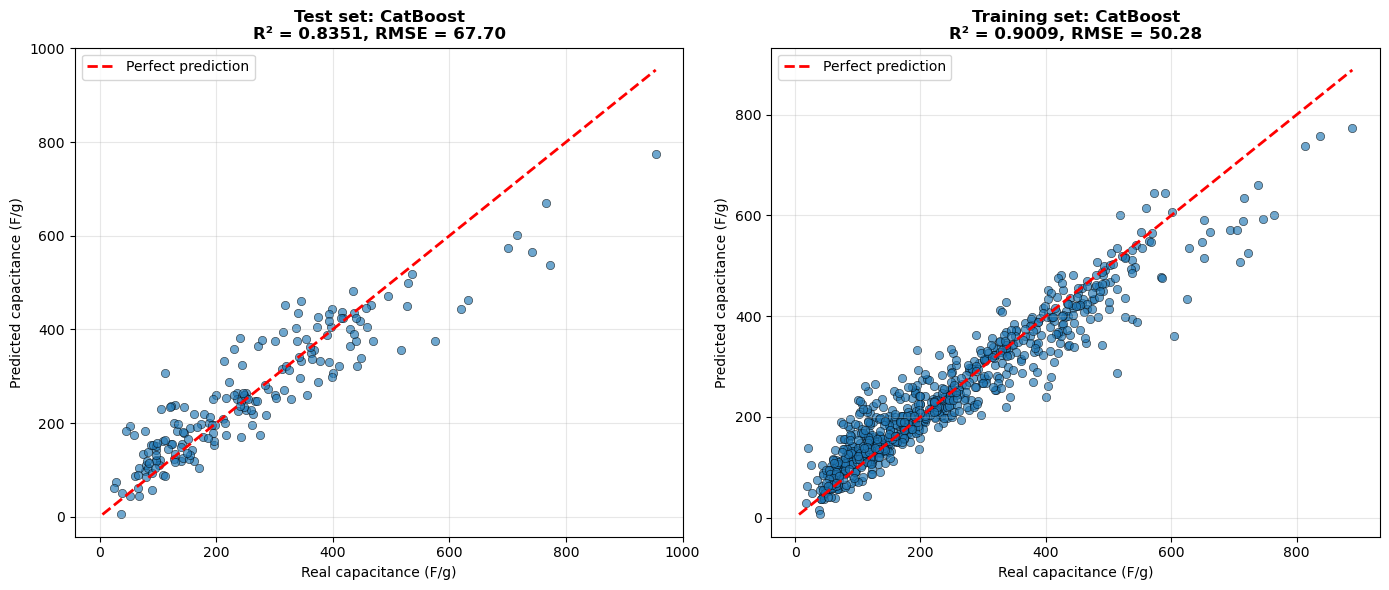

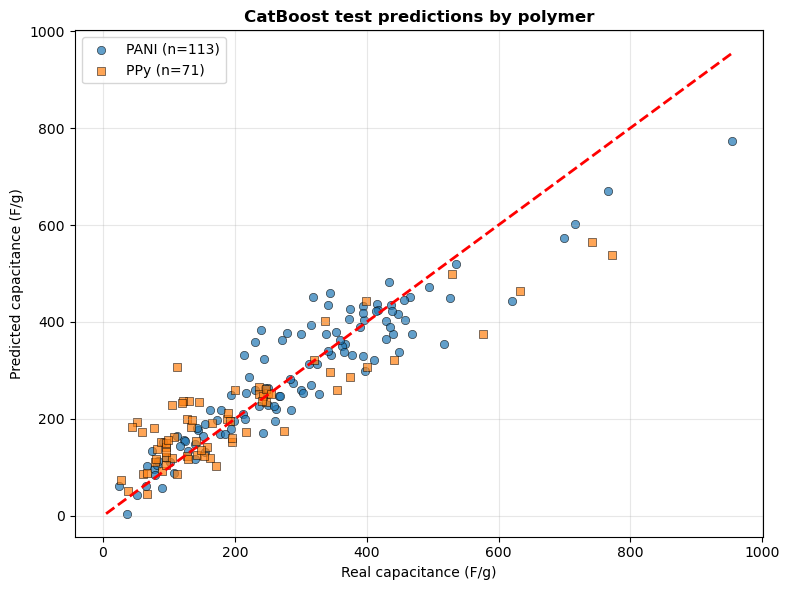


Saved model/results to: CatBoost


In [24]:
y_pred_train = optimized_model.predict(X_train)
y_pred_test = optimized_model.predict(X_test)


def make_prediction_frame(meta_part, split_name, y_true, y_pred):
    out = meta_part.reset_index(drop=True).copy()
    out["Split"] = split_name
    out["Real_Capacitance"] = np.asarray(y_true, dtype=float)
    out["Predicted_Capacitance"] = np.asarray(y_pred, dtype=float)
    out["Absolute_Error"] = (out["Real_Capacitance"] - out["Predicted_Capacitance"]).abs()
    eps = 1e-12
    out["Percentage_Error"] = np.where(
        np.abs(out["Real_Capacitance"]) > eps,
        out["Absolute_Error"] / np.abs(out["Real_Capacitance"]) * 100,
        np.nan,
    )
    return out


train_results_df = make_prediction_frame(meta_train, "Train", y_train, y_pred_train)
test_results_df = make_prediction_frame(meta_test, "Test", y_test, y_pred_test)
prediction_df = pd.concat([train_results_df, test_results_df], ignore_index=True)

metrics_df = build_metrics_table(prediction_df)
print("\n" + "=" * 70)
print("MODEL PERFORMANCE — ONE COMBINED CATBOOST MODEL")
print("=" * 70)
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

r2_gap = metrics_df[(metrics_df["Split"] == "Train-Test gap") & (metrics_df["Scope"] == "Combined")]["R2"].iloc[0]
rmse_gap = metrics_df[(metrics_df["Split"] == "Train-Test gap") & (metrics_df["Scope"] == "Combined")]["RMSE"].iloc[0]
if pd.notna(r2_gap) and r2_gap > 0.10:
    print(f"\n⚠ Possible overfitting: Train-Test R² gap = {r2_gap:.4f}; Test-Train RMSE gap = {rmse_gap:.4f}")
else:
    print("\n✓ Train-test gap looks acceptable by the 0.10 R² rule")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, title, real, pred in [
    (axes[0], "Test set", y_test, y_pred_test),
    (axes[1], "Training set", y_train, y_pred_train),
]:
    real = np.asarray(real, dtype=float)
    pred = np.asarray(pred, dtype=float)
    r2 = metrics.r2_score(real, pred)
    rmse = np.sqrt(metrics.mean_squared_error(real, pred))
    ax.scatter(real, pred, alpha=0.65, edgecolors="k", linewidth=0.5)
    lim_min = min(np.nanmin(real), np.nanmin(pred))
    lim_max = max(np.nanmax(real), np.nanmax(pred))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=2, label="Perfect prediction")
    ax.set_xlabel("Real capacitance (F/g)")
    ax.set_ylabel("Predicted capacitance (F/g)")
    ax.set_title(f"{title}: CatBoost\nR² = {r2:.4f}, RMSE = {rmse:.2f}", fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "CatBoost_predictions_train_test.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 6))
plot_df = test_results_df.copy()
for scope, marker in [("PANI", "o"), ("PPy", "s")]:
    s = plot_df[plot_df[POLYMER_COL].astype(str).eq(scope)]
    plt.scatter(
        s["Real_Capacitance"], s["Predicted_Capacitance"],
        label=f"{scope} (n={len(s)})", alpha=0.7, edgecolors="k", linewidth=0.5, marker=marker,
    )
lim_min = min(plot_df["Real_Capacitance"].min(), plot_df["Predicted_Capacitance"].min())
lim_max = max(plot_df["Real_Capacitance"].max(), plot_df["Predicted_Capacitance"].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=2)
plt.xlabel("Real capacitance (F/g)")
plt.ylabel("Predicted capacitance (F/g)")
plt.title("CatBoost test predictions by polymer", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "CatBoost_predictions_test_by_polymer.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cv_summary_df = pd.DataFrame({
    "Item": [
        "CV description", "Best penalized CV score", "Mean CV R2 test", "Std CV R2 test",
        "Mean CV R2 train", "Std CV R2 train", "CV overfit gap", "Alpha overfit gap",
        "Best parameters", "Grid search type",
    ],
    "Value": [
        cv_description, best_penalized, best_mean_test, best_std_test,
        best_mean_train, best_std_train, best_gap, ALPHA_OVERFIT_GAP,
        str(best_params), "Manual CV grid search; no sklearn GridSearchCV",
    ],
})

with pd.ExcelWriter(OUTPUT_DIR / "CatBoost_Combined_Results.xlsx", engine="openpyxl") as writer:
    train_results_df.to_excel(writer, sheet_name="Train_Results", index=False)
    test_results_df.to_excel(writer, sheet_name="Test_Results", index=False)
    prediction_df.to_excel(writer, sheet_name="All_Predictions", index=False)
    metrics_df.to_excel(writer, sheet_name="Performance_Metrics", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="Optimized_Parameters", index=False)
    cv_summary_df.to_excel(writer, sheet_name="CV_Summary", index=False)
    if RUN_GRID_SEARCH and not cv_results.empty:
        keep_cols = [
            "rank_test_score", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score",
            "overfit_gap", "penalized_score", "params",
        ]
        cv_results[keep_cols].head(200).to_excel(writer, sheet_name="GridSearch_Top200", index=False)

with open(OUTPUT_DIR / "CatBoost_combined_model.pkl", "wb") as f:
    pickle.dump(optimized_model, f)

try:
    optimized_model.save_model(str(OUTPUT_DIR / "CatBoost_combined_model.cbm"))
except Exception as exc:
    print(f"Could not save native CatBoost CBM model: {exc}")

print(f"\nSaved model/results to: {OUTPUT_DIR}")
